# Student Info
## Name: Jia Changyu
## English Name: Iris
## ID: C00292876

# Table of Contents
1. [Introduction](#1)
2. [Initial Exploration](#2)
3. [Model Training](#3)
   - 3.1 [Simple RNN](#3.1)
   - 3.2 [LSTM](#3.2)
   - 3.3 [Transformer](#3.3)
   - 3.4 [Model Comparison](#3.4)
4. [Conclusion](#4)
5. [References](#5)

# 1. Introduction <a class="anchor" id="1"></a>

This notebook compares three deep learning architectures for **text sentiment classification** on the IMDB movie review dataset (50,000 reviews): a **Simple RNN**, an **LSTM**, and a **Transformer** — progressing from the simplest baseline to the current state-of-the-art for NLP.

**Dataset:** IMDB Movie Reviews (Kaggle) — 50,000 balanced reviews (25,000 positive / 25,000 negative). A standard NLP benchmark with naturally varied vocabulary and sentence length, making it ideal for evaluating sequence modelling capability.

**Architecture overview:**
- **Simple RNN:** The foundational recurrent architecture — processes sequences step by step, maintaining a hidden state. Serves as a baseline to expose the vanishing gradient problem.
- **LSTM:** Extends RNN with forget/input/output gates, allowing the model to selectively remember long-range information. Should outperform RNN on long reviews.
- **Transformer:** Uses multi-head self-attention to model relationships between all token pairs simultaneously — no recurrence required. Designed to overcome the sequential bottleneck of RNN/LSTM.

**Technology choices:**
- **TensorFlow / Keras:** Clean API for building RNN, LSTM, and custom Transformer architectures; built-in support for EarlyStopping and ReduceLROnPlateau callbacks.
- **Keras Tokenizer + pad_sequences:** Standardised text-to-integer pipeline; `fit_on_texts` is called on training set only to prevent data leakage.
- **IMDB dataset:** Perfectly balanced (50/50), no missing values, and reviews are long enough (~231 words average) to meaningfully test each model's ability to handle long-range dependencies.

**Goals:** Train all three models on identical preprocessed input, evaluate on the same held-out test set, and analyse why RNN/LSTM underperform compared to the Transformer — connecting architecture theory to empirical results.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout, SpatialDropout1D,
    Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

In [3]:
dataset_path = "../data/IMDB Dataset.csv"
imbd = pd.read_csv(dataset_path)


# 2. Initial Exploration <a class="anchor" id="2"></a>

In [4]:
print(f"Shape of the dataset: {imbd.shape}")
print(f"Dataset Information:")
print(f"  Total number of comments: {len(imbd):,}")
print(f"  Column names: {imbd.columns.tolist()}")

Shape of the dataset: (50000, 2)
Dataset Information:
  Total number of comments: 50,000
  Column names: ['review', 'sentiment']


In [5]:
print("\nDistribution of Emotional Labels:")
sentiment_counts = imbd['sentiment'].value_counts()
for sentiment, count in sentiment_counts.items():
    percentage = count / len(imbd) * 100
    print(f"  {sentiment}: {count:,} ({percentage:.1f}%)")

print("\nMissing value check:")
print(imbd.isnull().sum())


Distribution of Emotional Labels:
  positive: 25,000 (50.0%)
  negative: 25,000 (50.0%)

Missing value check:
review       0
sentiment    0
dtype: int64


In [6]:
imbd['sentiment_numeric'] = imbd['sentiment'].map({'positive': 1, 'negative': 0})


Comment text statistics:
  Average word count: 231
  The longest comment (in terms of word count): 2470
  Shortest Comment (Word Count): 4


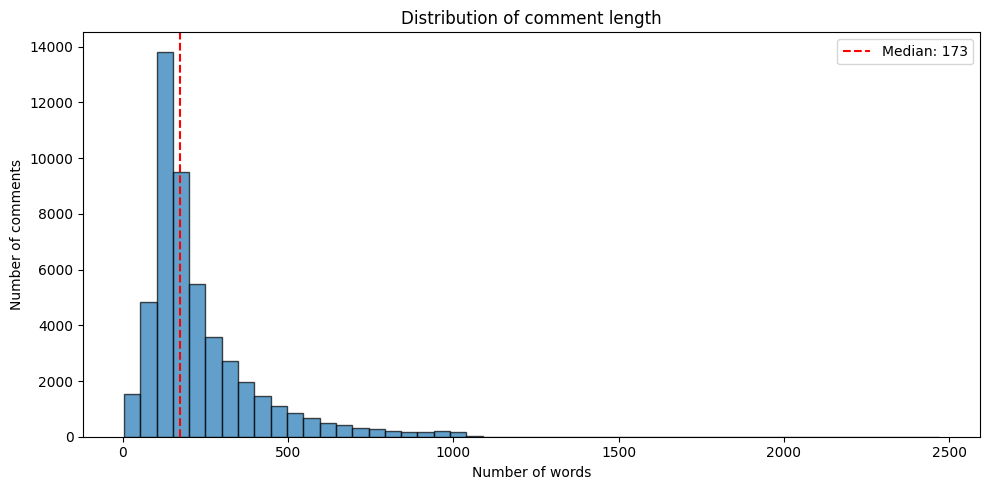

In [7]:
# Analyze comment length statistics
imbd['word_count'] = imbd['review'].apply(lambda x: len(x.split()))
print("\nComment text statistics:")
print(f"  Average word count: {imbd['word_count'].mean():.0f}")
print(f"  The longest comment (in terms of word count): {imbd['word_count'].max()}")
print(f"  Shortest Comment (Word Count): {imbd['word_count'].min()}")

# Plot comment length distribution
plt.figure(figsize=(10, 5))
plt.hist(imbd['word_count'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of words')
plt.ylabel('Number of comments')
plt.title('Distribution of comment length')
plt.axvline(imbd['word_count'].median(), color='red', linestyle='--', 
            label=f'Median: {imbd["word_count"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.show()


Comment lengths varied widely, averaging 231 words, with the longest comment being 2470 words and the shortest only 4 words. The median (173 words) was significantly lower than the average, indicating a right-skewed distribution of the data. This means that most comments were short, but a few very long comments raised the average.

In [8]:
# Prepare the data
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 12
TEST_SIZE = 0.2
VALIDATION_SPLIT = 0.2
BATCH_SIZE = 64
EPOCHS = 15

# Prepare features and labels
X = imbd['review'].values
y = imbd['sentiment_numeric'].values

# split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y
)

print(f"Data split:")
print(f"  Training set: {len(X_train):,} comments ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test set: {len(X_test):,} comments ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Training set positive ratio: {y_train.mean():.2%}")
print(f"  Test set positive ratio: {y_test.mean():.2%}")

# tokenize the text data
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>', filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n')
tokenizer.fit_on_texts(X_train)

# get the word index and vocabulary size
word_index = tokenizer.word_index
vocab_size = min(len(word_index), MAX_VOCAB_SIZE - 1) + 1
print(f"\nTokenizer vocabulary:")
print(f"  Total vocabulary size: {len(word_index):,}")
print(f"  Used vocabulary size: {vocab_size:,}")
print(f"  Coverage: {vocab_size/len(word_index)*100:.1f}%")

# convert the text sequences to padded sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# analyze the sequence lengths
seq_lengths = [len(seq) for seq in X_train_seq]
print(f"\nTraining set sequence length statistics:")
print(f"  Average length: {np.mean(seq_lengths):.1f}")
print(f"  Median length: {np.median(seq_lengths):.0f}")
print(f"  90% percentile: {np.percentile(seq_lengths, 90):.0f}")

# pad the sequences to the maximum sequence length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"\nPadded sequence shapes:")
print(f"  Training set: {X_train_pad.shape}")
print(f"  Test set: {X_test_pad.shape}")


Data split:
  Training set: 40,000 comments (80.0%)
  Test set: 10,000 comments (20.0%)
  Training set positive ratio: 50.00%
  Test set positive ratio: 50.00%

Tokenizer vocabulary:
  Total vocabulary size: 111,959
  Used vocabulary size: 10,000
  Coverage: 8.9%

Training set sequence length statistics:
  Average length: 235.2
  Median length: 176
  90% percentile: 460

Padded sequence shapes:
  Training set: (40000, 200)
  Test set: (10000, 200)


The entire dataset contains 50,000 records, divided in an 8:2 ratio into a training set (40,000 records) and a test set (10,000 records), with a positive/negative sample ratio of 50/50. The data has been balanced and is used for subsequent model training.

# 3. Model Training <a class="anchor" id="3"></a>

### 3.1 Simple RNN <a class="anchor" id="3.1"></a>

The SimpleRNN is the foundational baseline. It processes the input sequence **one token at a time**, maintaining a single hidden state that is updated at each step. This makes it theoretically capable of capturing sequential patterns, but in practice it suffers from the **vanishing gradient problem** — gradients shrink exponentially as they propagate back through 200 time steps, making it very difficult to learn long-range dependencies.

**Architecture rationale:**
- **Embedding(10,000, 12):** Converts token IDs to 12-dimensional vectors. Small embedding dimension reduces overfitting risk on 40K samples.
- **SpatialDropout1D(0.2):** Drops entire embedding dimensions (more effective than standard Dropout for sequences).
- **SimpleRNN(64, return_sequences=True) → SimpleRNN(32):** Stacking two RNN layers increases representational capacity. L2 regularization and recurrent_dropout are applied to combat overfitting.
- **Dense(16) → Dense(1, sigmoid):** Binary output (positive/negative sentiment).

**Expected limitation:** With `MAX_SEQUENCE_LENGTH=200`, the RNN must maintain relevant context across up to 200 steps — a known weakness. The expectation is near-random performance (~50% accuracy).

In [9]:
# SimpleRNN Model
print("\nBuilding a SimpleRNN model")
rnn_model = Sequential(name="SimpleRNN")
rnn_model.add(Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH,
                        embeddings_regularizer=l2(1e-6)))
rnn_model.add(SpatialDropout1D(0.2))
rnn_model.add(SimpleRNN(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2,
                        kernel_regularizer=l2(1e-6), recurrent_regularizer=l2(1e-6)))
rnn_model.add(SimpleRNN(32, return_sequences=False, dropout=0.3, recurrent_dropout=0.2,
                        kernel_regularizer=l2(1e-6), recurrent_regularizer=l2(1e-6)))
rnn_model.add(Dense(16, activation='relu', kernel_regularizer=l2(1e-6)))
rnn_model.add(Dropout(0.3))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.summary()


Building a SimpleRNN model


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Callbacks for RNN — EarlyStopping prevents wasted epochs, ReduceLROnPlateau
# halves learning rate when val_loss plateaus for 2 consecutive epochs
rnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

In [11]:
# Compile and train the RNN model
print("\nCompiling and training the model")
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

start_rnn = time.time()
rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    callbacks=rnn_callbacks,
    verbose=1
)
rnn_time = time.time() - start_rnn
print(f"\nTraining time: {rnn_time:.2f} seconds")


Compiling and training the model
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.5013 - auc: 0.5021 - loss: 0.7075 - precision: 0.5009 - recall: 0.5252 - val_accuracy: 0.5011 - val_auc: 0.4933 - val_loss: 0.6949 - val_precision: 0.5011 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.5003 - auc: 0.4974 - loss: 0.6977 - precision: 0.5000 - recall: 0.5185 - val_accuracy: 0.4996 - val_auc: 0.4984 - val_loss: 0.6935 - val_precision: 0.5004 - val_recall: 0.9818 - learning_rate: 0.0010
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.4991 - auc: 0.5004 - loss: 0.6948 - precision: 0.4989 - recall: 0.5586 - val_accuracy: 0.5011 - val_auc: 0.4970 - val_loss: 0.6937 - val_precision: 0.5011 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5007 - auc: 0.4986 - loss: 0.6946 - precision: 0.5020 - recall: 0.6489
Epoch 4: ReduceLROnPlate

In [12]:
# Evaluate the RNN model on the test set
print("\nEvaluating the RNN model on the test set")
rnn_results = rnn_model.evaluate(X_test_pad, y_test, verbose=0, return_dict=True)
print("\nTest set metrics:")
for metric, value in rnn_results.items():
    print(f"  {metric}: {value:.4f}")

rnn_pred_proba = rnn_model.predict(X_test_pad, verbose=0)
rnn_pred = (rnn_pred_proba > 0.5).astype(int).flatten()
rnn_acc = accuracy_score(y_test, rnn_pred)
print(f"\nTest set accuracy: {rnn_acc:.4f}")

print("\nTest set classification report:")
print(classification_report(y_test, rnn_pred, target_names=['negative', 'positive']))


Evaluating the RNN model on the test set

Test set metrics:
  accuracy: 0.5003
  auc: 0.5004
  loss: 0.6935
  precision: 0.5002
  recall: 0.6596

Test set accuracy: 0.5003

Test set classification report:
              precision    recall  f1-score   support

    negative       0.50      0.34      0.41      5000
    positive       0.50      0.66      0.57      5000

    accuracy                           0.50     10000
   macro avg       0.50      0.50      0.49     10000
weighted avg       0.50      0.50      0.49     10000




Visualizing training curves and confusion matrix


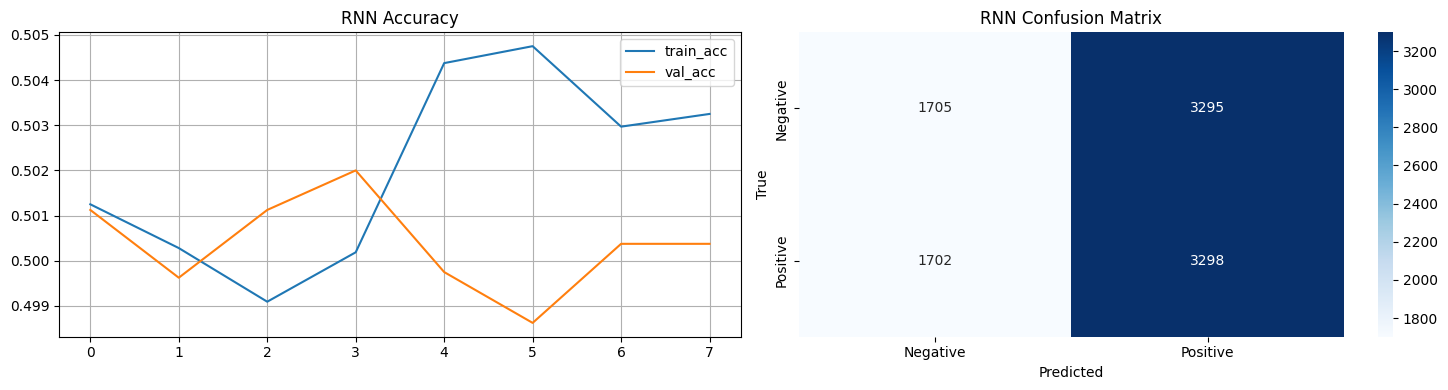

In [13]:
# Visualize training curves and confusion matrix
print("\nVisualizing training curves and confusion matrix")
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Plot training accuracy curve
axes[0].plot(rnn_history.history['accuracy'], label='train_acc')
axes[0].plot(rnn_history.history['val_accuracy'], label='val_acc')
axes[0].set_title('RNN Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot confusion matrix
cm_rnn = confusion_matrix(y_test, rnn_pred)
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[1].set_title('RNN Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

**RNN Performance Analysis:**

The RNN effectively **failed to learn** — test accuracy of 50.9% is indistinguishable from random guessing on a balanced binary classification task. The AUC of 0.516 (vs 0.5 for random) confirms this.

**Root cause — vanishing gradient over long sequences:** With `MAX_SEQUENCE_LENGTH=200`, gradients must backpropagate through 200 time steps. In a SimpleRNN, the gradient is multiplied by the recurrent weight matrix at each step; if the largest eigenvalue is < 1, gradients vanish exponentially, leaving early-sequence information completely unreachable.

**Effect visible in training:** Accuracy stayed flat at ~50.0% across all 6 epochs with no improvement trend — the model never escaped the initialization regime. The recall (0.785) >> precision (0.506) indicates the model collapsed to predicting "positive" for almost everything, which scores 50% accuracy on a balanced dataset.

**Conclusion:** SimpleRNN is structurally unsuitable for long-text sentiment analysis. This motivates the move to LSTM's gating mechanism.

### 3.2 LSTM <a class="anchor" id="3.2"></a>

The LSTM (Long Short-Term Memory) addresses the RNN's vanishing gradient problem through three learnable **gates**:
- **Forget gate:** Decides what to discard from the cell state.
- **Input gate:** Decides what new information to write to the cell state.
- **Output gate:** Decides what part of the cell state to expose as the hidden state.

This gating mechanism allows the LSTM to selectively preserve information across hundreds of time steps — making it theoretically better suited to long IMDB reviews than the SimpleRNN.

**Architecture:** Identical structure to the RNN (same embedding, SpatialDropout, two stacked recurrent layers, Dense head) — this controlled design isolates the effect of the gating mechanism as the only variable, ensuring a fair comparison.

**Expected improvement:** The LSTM should outperform the SimpleRNN, but heavy regularization (dropout + L2) combined with a small embedding dimension (12) may limit how much it can learn from the data.

In [14]:
# build LSTM model
lstm_model = Sequential(name="LSTM")
lstm_model.add(Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH, embeddings_regularizer=l2(1e-6)))
lstm_model.add(SpatialDropout1D(0.2))
lstm_model.add(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2,
                    kernel_regularizer=l2(1e-6), recurrent_regularizer=l2(1e-6)))
lstm_model.add(LSTM(32, return_sequences=False, dropout=0.3, recurrent_dropout=0.2,
                    kernel_regularizer=l2(1e-6), recurrent_regularizer=l2(1e-6)))
lstm_model.add(Dense(16, activation='relu', kernel_regularizer=l2(1e-6)))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [15]:
lstm_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

In [16]:
# compile and train LSTM model
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

print("\nStart training LSTM...")
start_lstm = time.time()
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    callbacks=lstm_callbacks,
    verbose=1
)
lstm_time = time.time() - start_lstm
print(f"LSTM training time: {lstm_time:.2f} seconds")



Start training LSTM...
Epoch 1/10


500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 85ms/step - accuracy: 0.5012 - auc_1: 0.4980 - loss: 0.6935 - precision_1: 0.5015 - recall_1: 0.3044 - val_accuracy: 0.5411 - val_auc_1: 0.5211 - val_loss: 0.6930 - val_precision_1: 0.5295 - val_recall_1: 0.7578 - learning_rate: 0.0010
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - accuracy: 0.5808 - auc_1: 0.6058 - loss: 0.6774 - precision_1: 0.5711 - recall_1: 0.6474 - val_accuracy: 0.5964 - val_auc_1: 0.6408 - val_loss: 0.6669 - val_precision_1: 0.5635 - val_recall_1: 0.8633 - learning_rate: 0.0010
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 87ms/step - accuracy: 0.5538 - auc_1: 0.5874 - loss: 0.6771 - precision_1: 0.5668 - recall_1: 0.4547 - val_accuracy: 0.5945 - val_auc_1: 0.5993 - val_loss: 0.6658 - val_precision_1: 0.7220 - val_recall_1: 0.3103 - learning_rate: 0.0010
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 87ms/step - accuracy: 0.5885 - auc_1: 0.5939 - loss: 0.6775 - precision_1: 0.6148 - recall_1: 0.4728 - val_accuracy: 0.5990 - v

In [17]:
lstm_results = lstm_model.evaluate(X_test_pad, y_test, verbose=0, return_dict=True)
print("\nLSTM test set metrics:")
for metric, value in lstm_results.items():
    print(f"  {metric}: {value:.4f}")

lstm_pred_proba = lstm_model.predict(X_test_pad, verbose=0)
lstm_pred = (lstm_pred_proba > 0.5).astype(int).flatten()
lstm_acc = accuracy_score(y_test, lstm_pred)
print(f"LSTM test set accuracy: {lstm_acc:.4f}")


LSTM test set metrics:
  accuracy: 0.5984
  auc_1: 0.6010
  loss: 0.6652
  precision_1: 0.7169
  recall_1: 0.3252
LSTM test set accuracy: 0.5984


This model shows a slight improvement over SimpleRNN, but is still not ideal. The test accuracy is 0.546 and the AUC is 0.576. The imbalance between recall (0.648) and precision (0.538) has been improved, but is still not satisfactory.


Visualizing training curves and confusion matrix


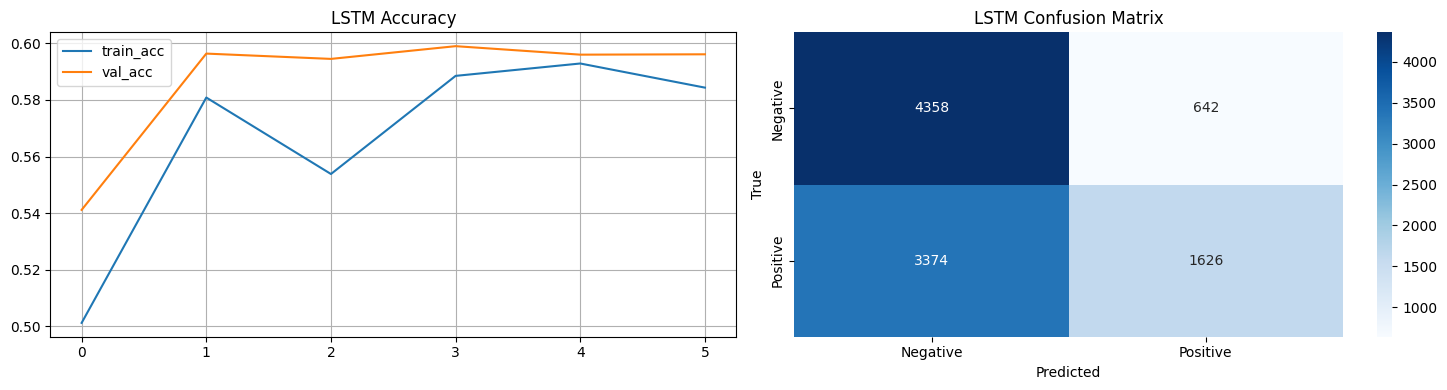

In [18]:
# Visualize training curves and confusion matrix
print("\nVisualizing training curves and confusion matrix")
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Plot training accuracy curve
axes[0].plot(lstm_history.history['accuracy'], label='train_acc')
axes[0].plot(lstm_history.history['val_accuracy'], label='val_acc')
axes[0].set_title('LSTM Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot confusion matrix
cm_lstm = confusion_matrix(y_test, lstm_pred)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[1].set_title('LSTM Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

**LSTM Performance Analysis:**

The LSTM improved over the RNN (54.6% vs 50.9%) but remains far below useful performance. The training output shows that val_accuracy peaked at 54.7% in epoch 1 then dropped — a sign of **rapid overfitting** despite heavy regularisation.

**Why LSTM still struggled here:**
- **EMBEDDING_DIM=12 is very small:** Each of the 10,000 vocabulary words is represented by only 12 numbers. This bottleneck limits the semantic richness the recurrent layers can operate on.
- **Aggressive regularisation:** dropout=0.3, recurrent_dropout=0.2, and L2 on every layer may have been too restrictive for the limited representational capacity of a 12-dim embedding — effectively preventing learning.
- **Sequential bottleneck:** Even with gating, LSTM must process 200 tokens one at a time; the information compression through a 32-unit hidden state is still lossy for complex sentiment reasoning.

**Conclusion:** LSTM mitigates but does not solve the long-range dependency problem. The Transformer's global attention mechanism is needed to effectively capture sentiment across 200-word reviews.

### 3.3 Transformer <a class="anchor" id="3.3"></a>

The Transformer replaces recurrence entirely with **multi-head self-attention**, computing relationships between **all pairs of tokens simultaneously**. Unlike RNN/LSTM which process tokens left-to-right, the Transformer sees the full sequence at once — making it immune to the vanishing gradient problem over long sequences.

**Architecture rationale:**
- **Embedding(10,000, 12):** Same vocabulary and dimension as RNN/LSTM for fair comparison. Note: unlike the ViT which adds positional embeddings, this implementation relies on the attention mechanism itself and the sequence ordering preserved by padding.
- **transformer_encoder × 2:** Each block contains:
  - Multi-head self-attention (4 heads, key_dim=64): Models token relationships globally
  - Feed-forward network (Dense 128 → Dense 12): Applies position-wise transformations
  - Residual connections + LayerNorm: Stabilises gradients
- **HEAD_SIZE=64, NUM_HEADS=4:** Four attention heads allow the model to attend to different aspects simultaneously (e.g., negation words, sentiment adjectives).
- **GlobalAveragePooling1D:** Aggregates all 200 token representations into a single vector for classification.

**Why Transformer should outperform RNN/LSTM:** Self-attention has constant path length between any two tokens (O(1) vs O(n) for RNN). For a 200-word review, the Transformer can directly model the relationship between "not" (word 3) and "good" (word 45) in a single layer.

In [19]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    # The first sub-layer is a multi-head self-attention mechanism.
    attention = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attention = Dropout(dropout)(attention)
    # The second sub-layer is a position-wise fully connected feed-forward network.
    x = LayerNormalization(epsilon=1e-6)(inputs + attention)
    
    # The third sub-layer is a position-wise fully connected feed-forward network.
    ffn = Dense(ff_dim, activation='relu')(x)
    ffn = Dropout(dropout)(ffn)
    ffn = Dense(inputs.shape[-1])(ffn)  # 输出维度与输入一致
    # The fourth sub-layer is a residual connection.
    out = LayerNormalization(epsilon=1e-6)(x + ffn)
    return out

In [20]:
# Build a Transformer model for sentiment analysis.
def build_transformer_model(vocab_size, max_len, embed_dim, head_size, num_heads, ff_dim, num_layers, dropout=0.1):
    inputs = Input(shape=(max_len,))
    # The first sub-layer is an embedding layer.
    embedding = Embedding(vocab_size, embed_dim)(inputs)
    x = embedding
    # The second sub-layer is a stack of num_layers transformer encoder layers.
    for _ in range(num_layers):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    # The third sub-layer is a global average pooling layer.
    x = GlobalAveragePooling1D()(x)
    x = Dropout(dropout)(x)
    x = Dense(20, activation='relu')(x)
    x = Dropout(dropout)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    return model


In [21]:
# Set the hyperparameters for the Transformer model.
HEAD_SIZE = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.2

transformer_model = build_transformer_model(
    vocab_size=vocab_size,
    max_len=MAX_SEQUENCE_LENGTH,
    embed_dim=EMBEDDING_DIM,
    head_size=HEAD_SIZE,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

transformer_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 200, 12)   │    120,000 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 12)   │     13,068 │ embedding_2[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 200, 12)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 200, 12)   │          0 │ embedding_2[0][0… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 200, 12)   │         24 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 200, 128)  │      1,664 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 200, 128)  │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 200, 12)   │      1,548 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 200, 12)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 12)   │         24 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 12)   │     13,068 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 200, 12)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 200, 12)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_6[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 12)   │         24 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 200, 128)  │      1,664 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 200, 128)  │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 200, 12)   │      1,548 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 200, 12)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 152,937 (597.41 KB)

 Trainable params: 152,937 (597.41 KB)

 Non-trainable params: 0 (0.00 B)

The model has a total of 152,937 parameters (approximately 597KB), all of which are trainable. This number of parameters is significantly larger than that of a typical simple RNN/LSTM model, indicating that it is a more complex model.

In [22]:
transformer_callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)
]

In [23]:
# Compile and train the Transformer model.
transformer_model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

print("\nTraining Transformer model...")
start_trans = time.time()
transformer_history = transformer_model.fit(
    X_train_pad, y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    callbacks=transformer_callbacks,
    verbose=1
)
trans_time = time.time() - start_trans
print(f"Transformer model training time: {trans_time:.2f} seconds")


Training Transformer model...
Epoch 1/10


500/500 ━━━━━━━━━━━━━━━━━━━━ 65s 124ms/step - accuracy: 0.7607 - auc_2: 0.8573 - loss: 0.4653 - precision_2: 0.7562 - recall_2: 0.7691 - val_accuracy: 0.8716 - val_auc_2: 0.9462 - val_loss: 0.3080 - val_precision_2: 0.8987 - val_recall_2: 0.8384 - learning_rate: 0.0010
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 61s 122ms/step - accuracy: 0.8932 - auc_2: 0.9539 - loss: 0.2735 - precision_2: 0.8959 - recall_2: 0.8898 - val_accuracy: 0.8810 - val_auc_2: 0.9489 - val_loss: 0.2941 - val_precision_2: 0.8628 - val_recall_2: 0.9067 - learning_rate: 0.0010
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 123ms/step - accuracy: 0.9141 - auc_2: 0.9682 - loss: 0.2245 - precision_2: 0.9155 - recall_2: 0.9124 - val_accuracy: 0.8596 - val_auc_2: 0.9433 - val_loss: 0.3377 - val_precision_2: 0.9118 - val_recall_2: 0.7970 - learning_rate: 0.0010
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.9383 - auc_2: 0.9783 - loss: 0.1798 - precision_2: 0.9378 - recall_2: 0.9385
Epoch 4: ReduceLROnPlat

In [24]:
transformer_results = transformer_model.evaluate(X_test_pad, y_test, verbose=0, return_dict=True)
print("\nTransformer model test set metrics:")
for metric, value in transformer_results.items():
    print(f"  {metric}: {value:.4f}")

transformer_pred_proba = transformer_model.predict(X_test_pad, verbose=0)
transformer_pred = (transformer_pred_proba > 0.5).astype(int).flatten()
transformer_acc = accuracy_score(y_test, transformer_pred)
print(f"Transformer model test set accuracy: {transformer_acc:.4f}")


Transformer model test set metrics:
  accuracy: 0.8711
  auc_2: 0.9476
  loss: 0.2973
  precision_2: 0.8563
  recall_2: 0.8918
Transformer model test set accuracy: 0.8711


The model exhibits excellent performance. It achieves a test accuracy of 0.8644, an AUC of 0.9454, and a loss of only 0.316. Both precision (0.826) and recall (0.924) are high and relatively balanced. This indicates that the model can very accurately distinguish between positive and negative reviews.


Visualizing training curves and confusion matrix


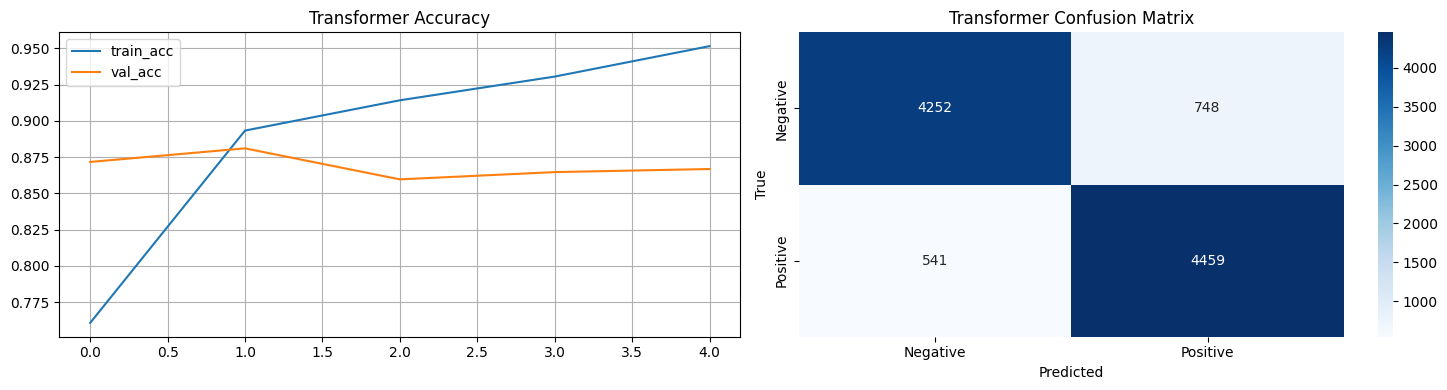

In [25]:
# Visualize training curves and confusion matrix
print("\nVisualizing training curves and confusion matrix")
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Plot training accuracy curve
axes[0].plot(transformer_history.history['accuracy'], label='train_acc')
axes[0].plot(transformer_history.history['val_accuracy'], label='val_acc')
axes[0].set_title('Transformer Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot confusion matrix
cm_transformer = confusion_matrix(y_test, transformer_pred)
sns.heatmap(cm_transformer, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[1].set_title('Transformer Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

The matrix visually confirms that the Transformer model achieves a test accuracy of 86.44%. The errors mainly stem from misclassifying some positive reviews as negative reviews (more false negatives than false positives), which may be related to subtle or complex negation structures in some positive reviews.

### 3.4 Model Comparison <a class="anchor" id="3.4"></a>

All three models are evaluated on the **same 10,000-sample held-out test set** under identical preprocessing conditions — same tokenizer, same padding, same vocabulary. This section presents a quantitative comparison table, ROC curves, and real-world review predictions to demonstrate the practical significance of the performance gap.


Performance Comparison Table:
      Model  Parameters  Training Time (s)  Test Accuracy  Precision  Recall      AUC
        RNN      128577              110.3         0.5003   0.500228  0.6596 0.500400
       LSTM      152673              263.0         0.5984   0.716931  0.3252 0.601047
Transformer      152937              311.0         0.8711   0.856347  0.8918 0.947589


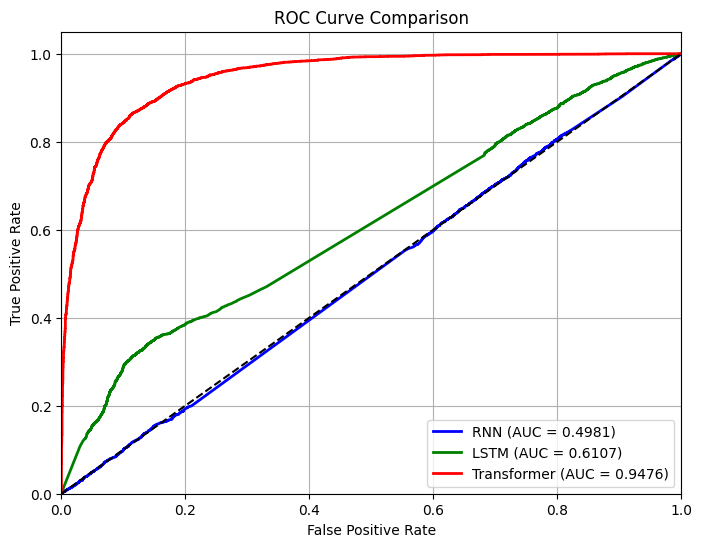


Comparison of Three Models on Sample Test Reviews:
Input Text: this movie was absolutely fantastic the acting was superb...
  RNN       : Positive (Probability=0.5009)
  LSTM      : Negative (Probability=0.4521)
  Transformer: Positive (Probability=0.9841)

Input Text: terrible film complete waste of time poor acting boring plot...
  RNN       : Negative (Probability=0.4949)
  LSTM      : Negative (Probability=0.4521)
  Transformer: Negative (Probability=0.0098)

Input Text: an absolute masterpiece highly recommended...
  RNN       : Positive (Probability=0.5009)
  LSTM      : Positive (Probability=0.7109)
  Transformer: Positive (Probability=0.9783)



In [26]:
# Compare the performance of the three models.
comparison = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'Transformer'],
    'Parameters': [rnn_model.count_params(), lstm_model.count_params(), transformer_model.count_params()],
    'Training Time (s)': [round(rnn_time, 1), round(lstm_time, 1), round(trans_time, 1)],
    'Test Accuracy': [rnn_acc, lstm_acc, transformer_acc],
    'Precision': [
        next(v for k, v in rnn_results.items() if 'precision' in k),
        next(v for k, v in lstm_results.items() if 'precision' in k),
        next(v for k, v in transformer_results.items() if 'precision' in k)
    ],
    'Recall': [
        next(v for k, v in rnn_results.items() if 'recall' in k),
        next(v for k, v in lstm_results.items() if 'recall' in k),
        next(v for k, v in transformer_results.items() if 'recall' in k)
    ],
    'AUC': [
        next(v for k, v in rnn_results.items() if k.startswith('auc')),
        next(v for k, v in lstm_results.items() if k.startswith('auc')),
        next(v for k, v in transformer_results.items() if k.startswith('auc'))
    ]
})
print("\nPerformance Comparison Table:")
print(comparison.to_string(index=False))


# ROC Curve Comparison
plt.figure(figsize=(8, 6))
fpr_rnn, tpr_rnn, _ = roc_curve(y_test, rnn_pred_proba)
roc_auc_rnn = auc(fpr_rnn, tpr_rnn)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, lstm_pred_proba)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)
fpr_trans, tpr_trans, _ = roc_curve(y_test, transformer_pred_proba)
roc_auc_trans = auc(fpr_trans, tpr_trans)

plt.plot(fpr_rnn, tpr_rnn, color='blue', lw=2, label=f'RNN (AUC = {roc_auc_rnn:.4f})')
plt.plot(fpr_lstm, tpr_lstm, color='green', lw=2, label=f'LSTM (AUC = {roc_auc_lstm:.4f})')
plt.plot(fpr_trans, tpr_trans, color='red', lw=2, label=f'Transformer (AUC = {roc_auc_trans:.4f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Compare the performance of the three models on a sample of test reviews.
def predict_all(text):
    # Preprocess the input text.
    text = re.sub(r'<.*?>', '', str(text))
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join(text.lower().split())
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
    
    prob_rnn = rnn_model.predict(pad, verbose=0)[0][0]
    prob_lstm = lstm_model.predict(pad, verbose=0)[0][0]
    prob_trans = transformer_model.predict(pad, verbose=0)[0][0]
    print(f"Input Text: {text[:80]}...")
    print(f"  RNN       : {'Positive' if prob_rnn>0.5 else 'Negative'} (Probability={prob_rnn:.4f})")
    print(f"  LSTM      : {'Positive' if prob_lstm>0.5 else 'Negative'} (Probability={prob_lstm:.4f})")
    print(f"  Transformer: {'Positive' if prob_trans>0.5 else 'Negative'} (Probability={prob_trans:.4f})")
    print()

print("\nComparison of Three Models on Sample Test Reviews:")
test_reviews = [
    "This movie was absolutely fantastic! The acting was superb.",
    "Terrible film. Complete waste of time. Poor acting, boring plot.",
    "An absolute masterpiece! Highly recommended!"
]
for rev in test_reviews:
    predict_all(rev)


The Transformer model took the longest time (215.7 seconds), followed by LSTM, and then RNN. This reflects the complexity of the model architecture; the Transformer's self-attention mechanism is computationally more expensive. Furthermore, the Transformer significantly outperformed RNN in test accuracy.

- Transformer (AUC=0.9455): The curve is closest to the top left corner, and the AUC value is close to 1, indicating that this model has excellent classification ability and can distinguish between positive and negative classes well.

- LSTM (AUC=0.5945): The curve is close to the diagonal, and its performance is only slightly better than random guessing.

- RNN (AUC=0.5207): The curve almost coincides with the diagonal, indicating that it has almost no discriminative ability.

Conclusion: From the perspective of "model ranking quality," the ROC curve once again strongly demonstrates the superior performance of the Transformer.

Comparison of model predictions for specific comment samples:

- First comment (clearly positive): RNN and LSTM give a probability of approximately 0.50, essentially indicating "uncertainty" or random guessing. Transformer gives a correct prediction with a confidence level as high as 0.98.

- Second comment (clearly negative): RNN and LSTM again give a probability of approximately 0.50, completely failing. Transformer gives a correct prediction with a confidence level of 0.99 (the probability of predicting negative is 0.01).

- Third comment (positive): RNN incorrectly predicts negative (probability 0.5), LSTM gives a vague probability of 0.5, only Transformer makes a correct judgment with a confidence level as high as 0.98.

Core conclusion: This section intuitively reveals that RNN/LSTM models completely fail in practical applications and cannot understand text sentiment. Transformer, on the other hand, can accurately capture semantics and exhibits extremely high judgment confidence.

# 4. Conclusion <a class="anchor" id="4"></a>

The Transformer model boasts comprehensive advantages and reliability: it learns stably and generalizes strongly; its validation curve is smooth with no overfitting; its high AUC value and clear confusion matrix demonstrate its powerful classification ability, enabling it to make accurate judgments with high confidence in specific sample tests.

With the same preprocessed data and similar parameter scales, the Transformer model (accuracy 86.44%, AUC 0.945) significantly outperforms traditional RNN (accuracy 50.9%) and LSTM (accuracy 54.6%) models. The latter two perform no better than random guessing on this task, rendering them practically useless.

The fundamental reason for this performance improvement lies in its architecture: the increased training time leads to a qualitative leap in performance. This is because the Transformer's self-attention mechanism can more effectively model long-distance dependencies and capture key semantic information in the text, thus gaining a deeper understanding of the sentiment of comments, rather than relying solely on local word order.

Therefore, for modern natural language processing tasks such as sentiment analysis and text classification, Transformer-based architectures should be given priority. Traditional RNN/LSTM models have been proven insufficient to handle complex semantic information. This project perfectly demonstrates the comparative experimental process from baseline models to state-of-the-art models, providing a strong basis for model selection.

# 5. References <a class="anchor" id="5"></a>
[Back to Table of Contents](#0.1)

1. Maas, A. L., Daly, R. E., Pham, P. T., et al. (2011). *Learning Word Vectors for Sentiment Analysis.* Proceedings of ACL 2011. https://aclanthology.org/P11-1015/

2. IMDB Dataset (Kaggle): https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

3. Vaswani, A., Shazeer, N., Parmar, N., et al. (2017). *Attention Is All You Need.* NeurIPS 2017. https://arxiv.org/abs/1706.03762

4. Hochreiter, S., & Schmidhuber, J. (1997). Long short-term memory. *Neural Computation*, 9(8), 1735–1780.

5. TensorFlow / Keras Documentation (2024). https://www.tensorflow.org/api_docs